<a href="https://colab.research.google.com/github/cs24dse009-ops/CSL701-CS34_Machine-Learning-Lab/blob/main/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Ayush Naik

Batch : CS2


Roll Number : CS34



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [3]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Load Breast Cancer Dataset
data = load_breast_cancer()

# Convert dataset into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add diagnosis column (0 = Malignant, 1 = Benign)
df['diagnosis'] = pd.Series(data.target).map({
    0: 'M',
    1: 'B'
})

# Display first five rows
print("First 5 Rows of Dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:", df.shape)

# Display number of samples and features
print("\nNumber of Samples:", df.shape[0])
print("Number of Features:", len(data.feature_names))

# Display diagnosis distribution
print("\nDiagnosis Distribution:")
print(df['diagnosis'].value_counts())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display dataset information
print("\nDataset Information:")
print(df.info())

First 5 Rows of Dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \


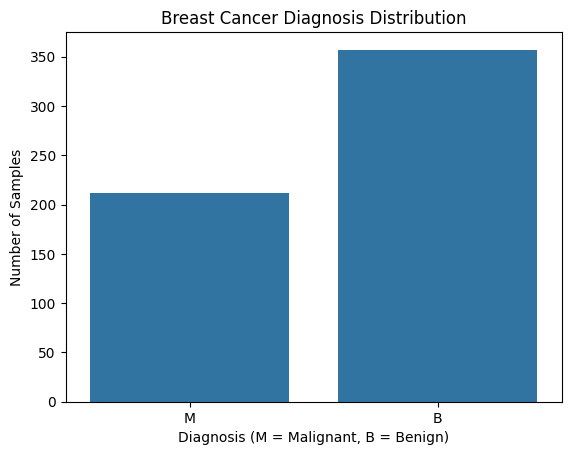

In [4]:
# Task 2: Explore the Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer Dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

# Add diagnosis column: M = Malignant, B = Benign
df['diagnosis'] = pd.Series(data.target).map({0: 'M', 1: 'B'})

# 1. Display first five rows
print("First 5 Rows:")
print(df.head())

# 2. Check dataset dimensions
print("\nDataset Dimensions:", df.shape)
print("Number of Samples:", df.shape[0])
print("Number of Features:", df.shape[1] - 1)

# 3. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# 4. Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 5. Check data types
print("\nColumn Data Types:")
print(df.dtypes)

# 6. Check diagnosis class distribution
print("\nDiagnosis Class Distribution:")
print(df['diagnosis'].value_counts())

# 7. Display diagnosis percentages
print("\nDiagnosis Distribution (%):")
print((df['diagnosis'].value_counts(normalize=True) * 100).round(2))

# 8. Visualize diagnosis distribution
sns.countplot(data=df, x='diagnosis')
plt.title("Breast Cancer Diagnosis Distribution")
plt.xlabel("Diagnosis (M = Malignant, B = Benign)")
plt.ylabel("Number of Samples")
plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [5]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load Breast Cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Select numerical features
X = df.select_dtypes(include=['number'])

# Check for non-informative identifier columns
X = X.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display results
print("Original Feature Dimensions:", X.shape)
print("Scaled Feature Dimensions:", X_scaled.shape)

print("\nFirst 5 Rows of Original Features:")
print(X.head())

print("\nFirst 5 Rows of Scaled Features:")
print(pd.DataFrame(X_scaled, columns=X.columns).head())

print("\nMean of Scaled Features (approximately 0):")
print(X_scaled.mean(axis=0).round(4))

print("\nStandard Deviation of Scaled Features (approximately 1):")
print(X_scaled.std(axis=0).round(4))

print("\nPreprocessing and scaling completed successfully!")

Original Feature Dimensions: (569, 30)
Scaled Feature Dimensions: (569, 30)

First 5 Rows of Original Features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

Pairwise Distance Matrix Shape: (569, 569)

First 5x5 Distance Matrix:
[[ 0.   10.32  6.78 10.47  8.67]
 [10.32  0.    5.03 16.25  4.38]
 [ 6.78  5.03  0.   12.84  4.46]
 [10.47 16.25 12.84  0.   15.38]
 [ 8.67  4.38  4.46 15.38  0.  ]]

Number of Nodes: 569
Number of Edges: 161596
Is Graph Complete: True


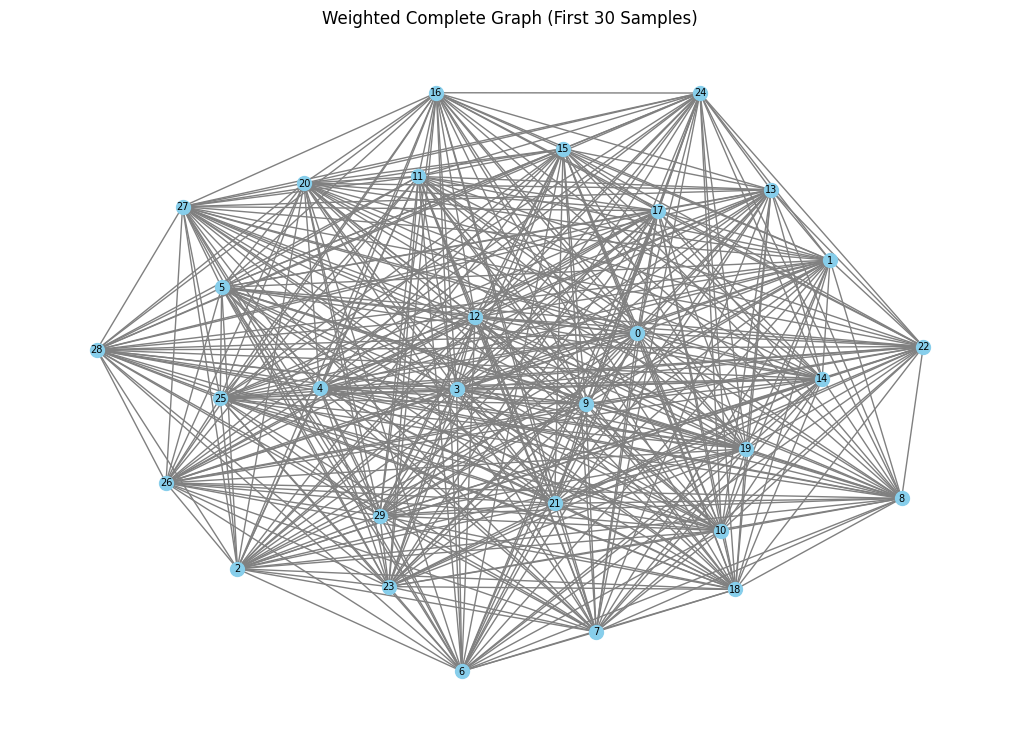

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric='euclidean'))

print("Pairwise Distance Matrix Shape:", distance_matrix.shape)
print("\nFirst 5x5 Distance Matrix:")
print(np.round(distance_matrix[:5, :5], 2))

# Construct weighted complete graph
G = nx.Graph()
n = X_scaled.shape[0]

# Add nodes for all samples
G.add_nodes_from(range(n))

# Add weighted edges between every pair of samples
for i in range(n):
    for j in range(i + 1, n):
        G.add_edge(i, j, weight=distance_matrix[i, j])

print("\nNumber of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())
print("Is Graph Complete:", nx.is_connected(G) and
      G.number_of_edges() == n * (n - 1) // 2)

# Visualize a small sample of the complete graph
sample_size = 30
G_sample = G.subgraph(range(sample_size))

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_sample, seed=42)
nx.draw(
    G_sample, pos,
    node_size=100,
    node_color='skyblue',
    edge_color='gray',
    with_labels=True,
    font_size=7
)
plt.title("Weighted Complete Graph (First 30 Samples)")
plt.show()

# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

Minimum Spanning Tree (MST) Computed Successfully!
Number of Nodes: 569
Number of Edges: 568

First 10 MST Connections and Weights:
Node 0 -- Node 77, Weight: 4.8299
Node 1 -- Node 365, Weight: 2.2871
Node 2 -- Node 45, Weight: 2.6763
Node 2 -- Node 77, Weight: 3.7056
Node 2 -- Node 535, Weight: 2.4515
Node 3 -- Node 190, Weight: 7.8710
Node 4 -- Node 498, Weight: 2.8827
Node 5 -- Node 8, Weight: 2.6951
Node 5 -- Node 31, Weight: 3.0699
Node 5 -- Node 47, Weight: 2.5029

Total MST Weight: 1393.8521


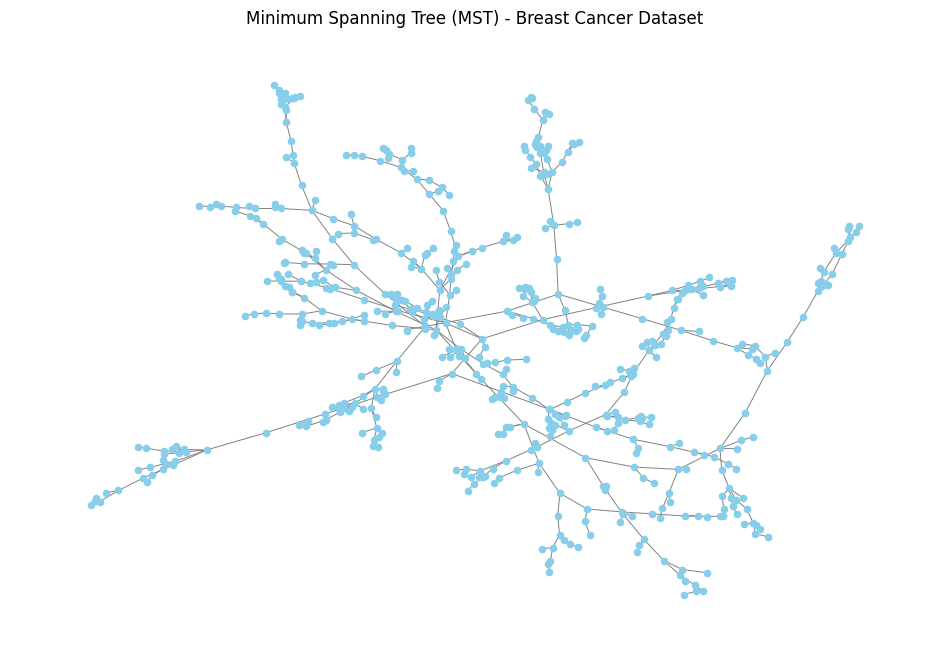

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import minimum_spanning_tree

# Compute Minimum Spanning Tree from the distance matrix
mst_matrix = minimum_spanning_tree(distance_matrix)

# Convert MST matrix to NetworkX graph
MST = nx.from_scipy_sparse_array(mst_matrix)

# Extract MST connections and weights
mst_edges = list(MST.edges(data=True))

print("Minimum Spanning Tree (MST) Computed Successfully!")
print("Number of Nodes:", MST.number_of_nodes())
print("Number of Edges:", MST.number_of_edges())

print("\nFirst 10 MST Connections and Weights:")
for u, v, data in mst_edges[:10]:
    print(f"Node {u} -- Node {v}, Weight: {data['weight']:.4f}")

# Calculate total MST weight
total_weight = sum(data['weight'] for _, _, data in mst_edges)
print("\nTotal MST Weight:", round(total_weight, 4))

# Visualize the MST
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(MST, seed=42)

nx.draw_networkx_nodes(MST, pos, node_size=20, node_color='skyblue')
nx.draw_networkx_edges(MST, pos, edge_color='gray', width=0.7)

plt.title("Minimum Spanning Tree (MST) - Breast Cancer Dataset")
plt.axis("off")
plt.show()

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [9]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.datasets import load_breast_cancer

# Load dataset with diagnosis labels
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = pd.Series(data.target).map({0: 'M', 1: 'B'})

# Copy the MST
G_cluster = MST.copy()

# Sort MST edges in descending order by weight
sorted_edges = sorted(
    G_cluster.edges(data=True),
    key=lambda edge: edge[2]['weight'],
    reverse=True
)

# Remove the largest edge to create K=2 clusters
u, v, edge_data = sorted_edges[0]
print("Largest MST Edge:")
print(f"Node {u} -- Node {v}, Weight: {edge_data['weight']:.4f}")

G_cluster.remove_edge(u, v)

# Find connected components
components = list(nx.connected_components(G_cluster))

# Assign cluster labels
cluster_labels = np.zeros(len(df), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Add cluster labels to the dataset
df['Cluster'] = cluster_labels

# Display results
print("\nNumber of Clusters:", len(components))
print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

print("\nDataset with Cluster Labels:")
print(df[['diagnosis', 'Cluster']].head(10))

print("\nDiagnosis vs Cluster:")
print(pd.crosstab(df['diagnosis'], df['Cluster']))

print("\nGraph-Based Clustering Completed Successfully!")

Largest MST Edge:
Node 461 -- Node 503, Weight: 12.2999

Number of Clusters: 2

Cluster Sizes:
Cluster
0    567
1      2
Name: count, dtype: int64

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Dataset with Cluster Labels:
  diagnosis  Cluster
0         M        0
1         M        0
2         M        0
3         M        0
4         M        0
5         M        0
6         M        0
7         M        0
8         M        0
9         M        0

Diagnosis vs Cluster:
Cluster      0  1
diagnosis        
B          357  0
M          210  2

Graph-Based Clustering Completed Successfully!


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [10]:
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.datasets import load_breast_cancer

# Load ground-truth diagnosis labels
data = load_breast_cancer()
y_true = data.target

# Use cluster_labels from Task 6
y_pred = cluster_labels

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, y_pred)
ari_score = adjusted_rand_score(y_true, y_pred)
nmi_score = normalized_mutual_info_score(y_true, y_pred)

# Display results
print("MST Clustering Performance Evaluation")
print("-------------------------------------")
print("Silhouette Score:", round(sil_score, 4))
print("Adjusted Rand Index (ARI):", round(ari_score, 4))
print("Normalized Mutual Information (NMI):", round(nmi_score, 4))

MST Clustering Performance Evaluation
-------------------------------------
Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

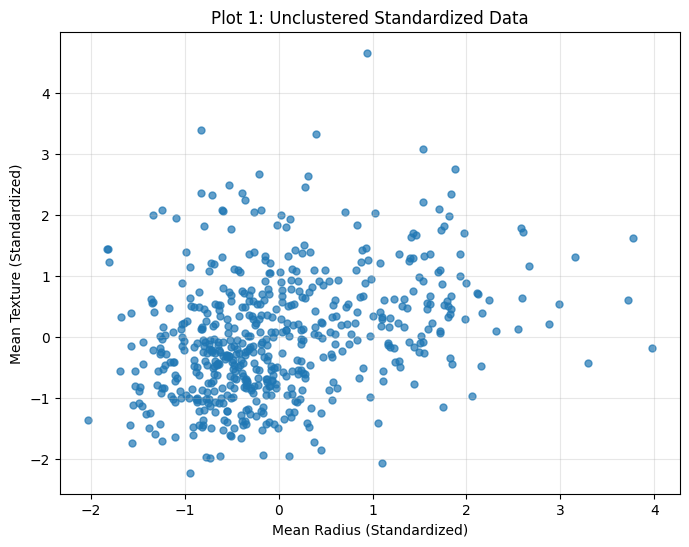

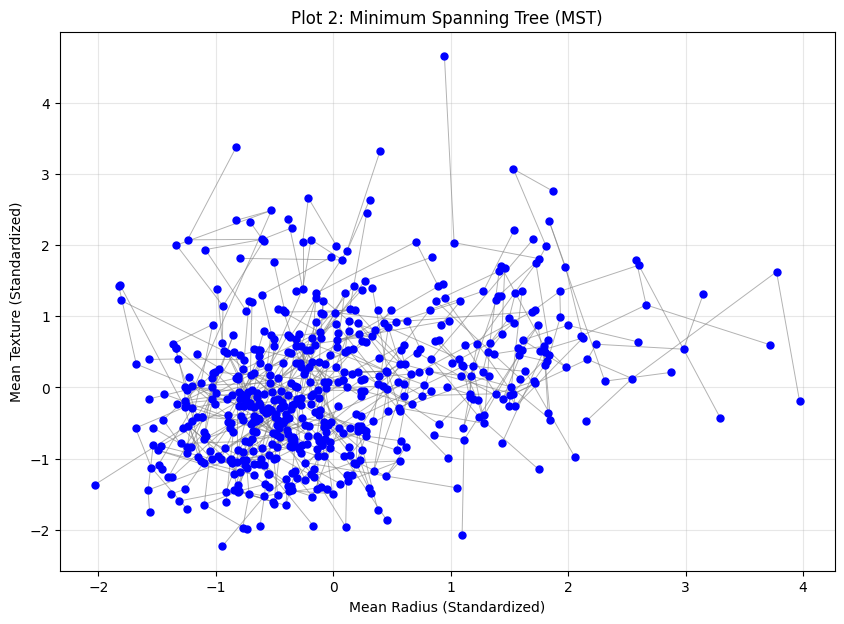

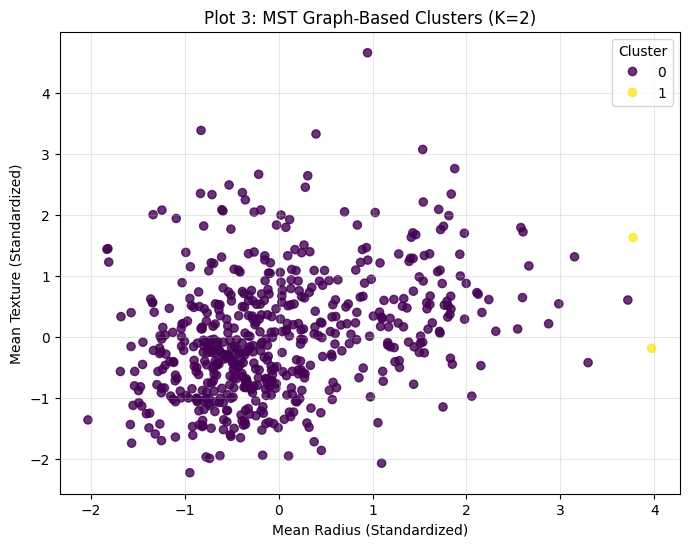

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
feature_names = list(data.feature_names)

# Select mean radius and mean texture
radius_idx = feature_names.index('mean radius')
texture_idx = feature_names.index('mean texture')

# Extract standardized features
X_2d = X_scaled[:, [radius_idx, texture_idx]]

# Plot 1: Unclustered standardized data
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=25, alpha=0.7)
plt.title("Plot 1: Unclustered Standardized Data")
plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: MST overlaid on standardized data
plt.figure(figsize=(10, 7))

for u, v in MST.edges():
    plt.plot(
        [X_2d[u, 0], X_2d[v, 0]],
        [X_2d[u, 1], X_2d[v, 1]],
        color='gray', linewidth=0.7, alpha=0.6
    )

plt.scatter(X_2d[:, 0], X_2d[:, 1], s=25, color='blue', zorder=2)
plt.title("Plot 2: Minimum Spanning Tree (MST)")
plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Final clusters after removing the largest MST edge
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=cluster_labels, cmap='viridis',
    s=35, alpha=0.8
)

plt.title("Plot 3: MST Graph-Based Clusters (K=2)")
plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.